# $\text{Taller: Autoencoders Variacionales (VAE)}$

## $\text{Generación de Ropa con Fashion-MNIST}$

---
## $\text{Tabla de Contenido}$

1. $\text{Importar Librerías}$
2. $\text{Introducción a los Autoencoder Variacional}$
3. $\text{Carga y Preparación de Datos (Fashion-MNIST)}$
4. $\text{Construcción de un Autoencoder Convolucional (AE) Base}$
5. $\text{Construcción y Entrenamiento del Autoencoder Variacional (VAE)}$
6. $\text{Generación y Exploración del Espacio Latente}$

## 1. $\text{Importar Librerías}$

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

## 2. $\text{Introducción a los Autoencoder Variacional}$

### ¿Qué es un Autoencoder Variacional (VAE)?

| **Componente Clave**                | **Función en el VAE**                                                                 | **Analogía del "Artista Organizado"**                                                                 |
|------------------------------------|----------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------|
| **Encoder Probabilístico**         | En lugar de un punto, mapea la entrada a una distribución de probabilidad (media $\mu$ y varianza $\sigma^2$). | El artista no escribe notas exactas, sino que dibuja una "nube de posibilidades" para la esencia de la foto. |
| **Espacio Latente ($z$)**          | Un vector muestreado de la distribución ($z = \mu + \varepsilon \cdot \sigma$). Introduce aleatoriedad controlada. | Se toma una "nota" al azar de dentro de esa nube de posibilidades.                                   |
| **Decoder**                        | Reconstruye la imagen original a partir del vector latente $z$, igual que en un AE estándar.         | El artista redibuja la foto usando solo la nota muestreada.                                          |
| **Pérdida de Reconstrucción**      | Mide qué tan parecida es la imagen reconstruida a la original (e.g., Entropía Cruzada Binaria).        | El dibujo final debe parecerse al original. ¡El artista debe ser un buen copista!                    |
| **Pérdida de Regularización (KL)** | Fuerza a que las distribuciones aprendidas en el espacio latente se parezcan a una normal estándar $\mathcal{N}(0, 1)$. | Todas las "nubes de posibilidades" deben estar bien organizadas y cerca del centro del "tablero de notas", no dispersas. |

---

### La Magia del VAE

Al forzar este espacio latente a ser **organizado y continuo**, podemos tomar un punto aleatorio $z$ y el Decoder sabrá cómo **interpretarlo** para generar una imagen completamente **nueva y realista**.


## 3. $\text{Carga y Preparación de Datos (Fashion-MNIST)}$


### 3.1 Cargar y Preparar el Dataset

- Define las constantes globales que usaremos: un tamaño de imagen (IMG_SHAPE) de 28x28, un tamaño de lote (BATCH_SIZE) de 256, y una dimensión para nuestro espacio latente (LATENT_DIM) de 2. Usaremos 2 dimensiones para poder visualizar el espacio latente fácilmente más adelante.
- `Usa keras.datasets.fashion_mnist.load_data() `para cargar el dataset. Esta función devuelve los datos ya separados en conjuntos de entrenamiento y prueba.
- Haga un sampleo *adecuado*.

In [ ]:
# --- Configuración de Hiperparámetros y Constantes ---
IMG_SHAPE = (28, 28, 1) # Las imágenes son de 28x28 en escala de grises (1 canal)
BATCH_SIZE = 256
LATENT_DIM = 2 # ¡Importante! Usamos 2D para poder visualizar el espacio latente

# --- Cargar el Dataset ---
# Keras nos facilita la vida cargando el dataset directamente.
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# x_train = x_train[:6000]
# y_train = y_train[:6000]
# x_test = x_test[:1500]
# y_test = y_test[:1500]

In [ ]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

### 3.2 Preprocesamiento de las Imágenes

- Une los conjuntos de entrenamiento y prueba en un solo gran dataset. Para un VAE, a menudo queremos que aprenda la distribución de todos los datos disponibles.
- Normaliza los valores de los píxeles para que estén en el rango de 0 a 1 (dividiendo por 255).
- Añade una dimensión de canal al final de las imágenes (de (28, 28) a (28, 28, 1)), ya que las capas convolucionales de Keras esperan esta dimensión.
- Imprime **10** ejemplos del dataset Fashion-MNIST (ya aplanados y normalizados)

In [ ]:
# --- Preprocesamiento de las Imágenes ---
# Juntamos los datos de entrenamiento y prueba
todas_las_imagenes = np.concatenate([x_train, x_test], axis=0)

# Normalizamos y añadimos la dimensión del canal
todas_las_imagenes = np.expand_dims(todas_las_imagenes, -1).astype("float32") / 255.0

print(f"Forma final de los datos (muestras, alto, ancho, canales): {todas_las_imagenes.shape}")

Forma final de los datos (muestras, alto, ancho, canales): (70000, 28, 28, 1)


Ejemplos del dataset Fashion-MNIST (ya aplanados y normalizados):


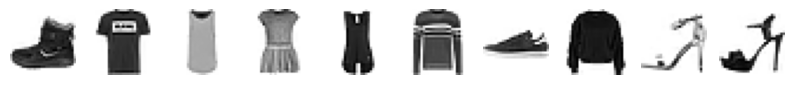

In [ ]:
n_ejemplos = 10
plt.figure(figsize=(10, 2))
print("Ejemplos del dataset Fashion-MNIST (ya aplanados y normalizados):")
for i in range(n_ejemplos):
    ax = plt.subplot(1, n_ejemplos, i + 1)
    # Para visualizar, necesitamos remodelar el vector de 784 a una imagen de 28x28.
    plt.imshow(todas_las_imagenes[i].reshape(28, 28), cmap="binary")
    plt.axis("off")
plt.show()

### 3.3 Crear el Pipeline de Datos con tf.data

Ahora, convierte nuestro array de NumPy en un objeto` tf.data.Dataset`. Esto nos permite usar métodos eficientes como .shuffle(), .batch(), y .prefetch() para alimentar los datos a nuestro modelo durante el entrenamiento.

In [ ]:
# Es crucial que creemos una tupla donde la entrada y el objetivo son los mismos.
train_dataset = tf.data.Dataset.from_tensor_slices((todas_las_imagenes, todas_las_imagenes))

# Barajamos los datos, los agrupamos en lotes y usamos prefetch para optimizar la carga
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("\nDataset preparado y listo para el entrenamiento.")


Dataset preparado y listo para el entrenamiento.


## 4. $\text{Construcción del Autoencoder Convolucional (AE) Base}$

Empezaremos con un Autoencoder estándar para entender las piezas. Construiremos un Encoder y un Decoder usando la API Funcional de Keras.

### 4.1 Arquitectura del Encoder

Define el Encoder. Debe tomar una imagen de 28x28x1 y comprimirla en un vector de tamaño LATENT_DIM. Sigue esta arquitectura convolucional:
- Capa de Entrada.
- Conv2D con 32 filtros, kernel 3x3, strides=2, activación relu.
- Conv2D con 64 filtros, kernel 3x3, strides=2, activación relu.
- Flatten.
- Dense como capa de salida para el espacio latente.

In [ ]:
# Limpiar la sesión de Keras para empezar de cero
keras.backend.clear_session()

# --- 4.1. Definición de la Arquitectura del Encoder ---
encoder_inputs = keras.Input(shape=IMG_SHAPE)
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
latent_space_ae = layers.Dense(LATENT_DIM, name="espacio_latente_ae")(x)
encoder_ae = keras.Model(encoder_inputs, latent_space_ae, name="encoder_ae")
print("--- Resumen del Encoder del AE ---")
encoder_ae.summary()

# # Limpiar la sesión de Keras para empezar de cero y evitar conflictos de nombres
# keras.backend.clear_session()

# # --- 4.1. Definición de la Arquitectura del Encoder ---
# # 1. Definimos la entrada que espera el Encoder: una imagen 28x28 con 1 canal (escala de grises).
# encoder_inputs = keras.Input(shape=IMG_SHAPE, name="entrada_encoder")

# # 2. Primera Capa Convolucional
# # Toma la imagen de entrada y aplica 32 filtros diferentes para detectar patrones básicos.
# # strides=2 reduce el tamaño de la imagen a la mitad (de 28x28 a 14x14).
# x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)

# # 3. Segunda Capa Convolucional
# # Toma los 32 mapas de características de la capa anterior y aplica 64 filtros nuevos
# # para encontrar patrones más complejos. Vuelve a reducir el tamaño a la mitad (de 14x14 a 7x7).
# x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)

# # 4. Capa de Aplanamiento (Flatten)
# # Los mapas de características 2D se "desenrollan" en un único y largo vector.
# x = layers.Flatten()(x)

# # 5. Capa Densa de Salida
# # Comprime el vector largo en nuestro vector final del espacio latente de solo 2 dimensiones.
# latent_space_ae = layers.Dense(LATENT_DIM, name="espacio_latente_ae")(x)

# # 6. Creamos el modelo del Encoder
# # Le decimos a Keras: "Este modelo empieza en 'encoder_inputs' y termina en 'latent_space_ae'".
# encoder_ae = keras.Model(encoder_inputs, latent_space_ae, name="encoder_ae")
# print("--- Resumen del Encoder del AE ---")
# encoder_ae.summary()

--- Resumen del Encoder del AE ---


Model: "encoder_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ espacio_latente_ae (Dense)      │ (None, 2)              │         6,274 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,090 (98.01 KB)

 Trainable params: 25,090 (98.01 KB)

 Non-trainable params: 0 (0.00 B)

### 4.2. Arquitectura del Decoder

Ahora, construye el Decoder. Debe hacer el proceso inverso: tomar un vector del espacio latente y reconstruir una imagen de 28x28x1. La arquitectura debe ser la inversa simétrica del encoder.

In [ ]:
# --- 4.2. Definición de la Arquitectura del Decoder ---
latent_inputs_ae = keras.Input(shape=(LATENT_DIM,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs_ae)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs_ae = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder_ae = keras.Model(latent_inputs_ae, decoder_outputs_ae, name="decoder_ae")
print("\n--- Resumen del Decoder del AE ---")
decoder_ae.summary()

# # --- 4.2. Definición de la Arquitectura del Decoder ---
# # 1. Definimos la entrada que espera el Decoder: un vector de 2 dimensiones.
# latent_inputs_ae = keras.Input(shape=(LATENT_DIM,), name="entrada_decoder")

# # 2. Expandimos el vector latente para que tenga el mismo número de neuronas que tenía
# # el vector aplanado en el encoder (3136).
# x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs_ae)

# # 3. Remodelamos el vector para que vuelva a tener la forma 3D de un mapa de características.
# x = layers.Reshape((7, 7, 64))(x)

# # 4. Usamos capas Conv2DTranspose para "des-convolucionar" y aumentar el tamaño de la imagen.
# # Es la operación inversa de una Conv2D con strides=2.
# # De 7x7 a 14x14
# x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
# # De 14x14 a 28x28
# x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)

# # 5. La capa final reconstruye la imagen a su tamaño original con 1 canal de color.
# # Usamos activación 'sigmoid' para que los valores de los píxeles estén entre 0 y 1.
# decoder_outputs_ae = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)

# # 6. Creamos el modelo del Decoder.
# decoder_ae = keras.Model(latent_inputs_ae, decoder_outputs_ae, name="decoder_ae")
# print("\n--- Resumen del Decoder del AE ---")
# decoder_ae.summary()


--- Resumen del Decoder del AE ---


Model: "decoder_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

### 4.3 Compilación y Entrenamiento del Autoencoder Completo

- Conecta el `encoder_ae` y el `decoder_ae` para formar el autoencoder completo.
- Compílalo con el optimizador `'adam' `y la pérdida `'binary_crossentropy'`.
- Entrénalo durante 20 épocas. Al método `.fit()`, pásale `train_dataset` tanto para x como para y
- Visualice las reconstrucciones


--- Entrenando el Autoencoder Estándar (AE) ---
Epoch 1/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - loss: 0.4925
Epoch 2/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.3425
Epoch 3/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.3369
Epoch 4/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.3343
Epoch 5/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.3325
Epoch 6/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.3316
Epoch 7/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.3305 
Epoch 8/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.3300 
Epoch 9/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.3291
Epoch 10/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.3286
Epoch 11/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.3280
Epoch 12/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.3276
Epoch 13/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.3277
Epoch 14/30
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0

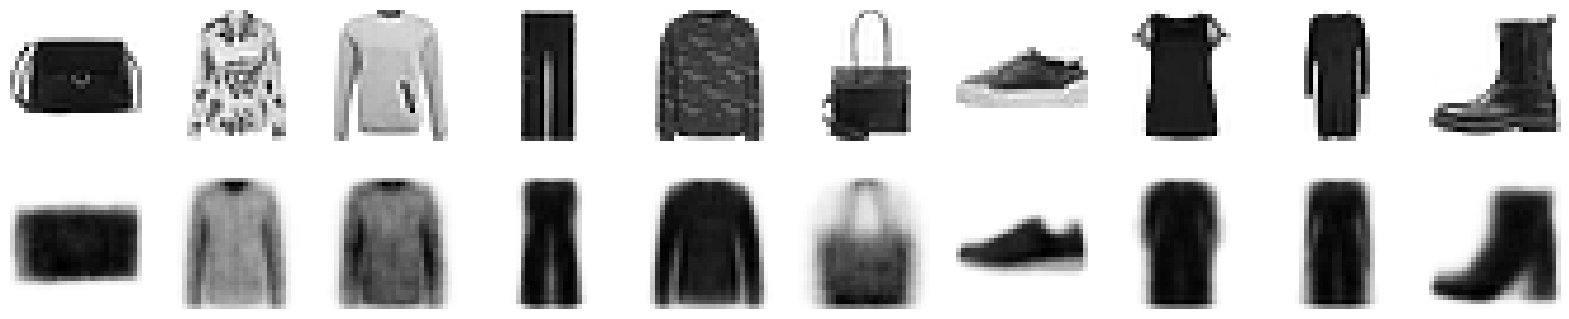

In [ ]:
# --- 4.3. Construcción, Compilación y Entrenamiento del AE ---
# Limpiar la sesión de Keras por si se re-ejecuta la celda
keras.backend.clear_session()

# # Re-definir las piezas para asegurar un grafo limpio
# encoder_inputs = keras.Input(shape=IMG_SHAPE, name="entrada_encoder")
# x_enc = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
# x_enc = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x_enc)
# x_enc = layers.Flatten()(x_enc)
# latent_space_ae = layers.Dense(LATENT_DIM, name="espacio_latente_ae")(x_enc)
# encoder_ae = keras.Model(encoder_inputs, latent_space_ae, name="encoder_ae")

# latent_inputs_ae = keras.Input(shape=(LATENT_DIM,))
# x_dec = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs_ae)
# x_dec = layers.Reshape((7, 7, 64))(x_dec)
# x_dec = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x_dec)
# x_dec = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x_dec)
# decoder_outputs_ae = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x_dec)
# decoder_ae = keras.Model(latent_inputs_ae, decoder_outputs_ae, name="decoder_ae")

# Conectar las piezas
autoencoder_output = decoder_ae(encoder_ae(encoder_inputs))
autoencoder = keras.Model(encoder_inputs, autoencoder_output, name="autoencoder")
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

# Entrenar
print("\n--- Entrenando el Autoencoder Estándar (AE) ---")
history_ae = autoencoder.fit(
    train_dataset,
    epochs=30, # suficiente para convergencia básica
    verbose=1
)

# Visualizar reconstrucciones (FUNCIÓN CORREGIDA)
def plot_reconstrucciones(model, dataset, n_imagenes=10):
    plt.figure(figsize=(20, 4))
    print("\nFila superior: Originales / Fila inferior: Reconstruidas")
    for imagenes, _ in dataset.take(1):
        reconstruidas = model.predict(imagenes, verbose=0)

        # Convertir los tensores a arrays de NumPy ANTES de graficar
        imagenes_np = imagenes.numpy()
        reconstruidas_np = reconstruidas

        for i in range(n_imagenes):
            ax = plt.subplot(2, n_imagenes, i + 1)
            # Ahora usamos .reshape en el array de NumPy
            plt.imshow(imagenes_np[i].reshape(28, 28), cmap="binary")
            plt.axis("off")

            ax = plt.subplot(2, n_imagenes, i + 1 + n_imagenes)
            plt.imshow(reconstruidas_np[i].reshape(28, 28), cmap="binary")
            plt.axis("off")
    plt.show()

plot_reconstrucciones(autoencoder, train_dataset)

## 5. Construcción y Entrenamiento del Autoencoder Variacional (VAE)

### 5.1. Clase VAE (Proporcionada)

In [ ]:
# Clase VAE

# Esta es la "plantilla" de nuestro VAE. Es la forma moderna y recomendada por Keras
# para construir modelos con una lógica de entrenamiento personalizada. No necesitan modificarla,
# pero es muy importante que lean los comentarios para entender cómo funciona el VAE.
# Piensen en esto como un formulario con 3 secciones principales que rellenamos.

class VAE(keras.Model):
    # --- SECCIÓN 1: El Constructor `__init__` ---
    # ¿Qué piezas necesita nuestro VAE para existir?
    # Le pasamos el encoder y el decoder que construiremos por separado.
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs) # Inicialización estándar de un modelo Keras
        self.encoder = encoder
        self.decoder = decoder
        # También preparamos unos "contadores" (métricas) para llevar un registro
        # de nuestras pérdidas durante el entrenamiento y poder visualizarlas.
        self.total_loss_tracker = keras.metrics.Mean(name="loss_total")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="loss_reconstruccion")
        self.kl_loss_tracker = keras.metrics.Mean(name="loss_kl")

    # --- Propiedad `metrics` ---
    # Le decimos a Keras qué "contadores" queremos que nos muestre en la barra de progreso
    # durante cada época de entrenamiento.
    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    # --- SECCIÓN 2: El Corazón del Aprendizaje `train_step` ---
    # Aquí definimos la "receta" exacta para UN solo paso de entrenamiento.
    # Keras llamará a esta función automáticamente con cada lote de datos.
    def train_step(self, data):
        # Nuestro dataset produce tuplas (imagen, imagen). Tomamos la primera.
        x = data[0] if isinstance(data, tuple) else data

        # GradientTape es como una "grabadora" de operaciones. TensorFlow la usa para
        # "rebobinar" y calcular los gradientes automáticamente (backpropagation).
        with tf.GradientTape() as tape:
            # --- FORWARD PASS (Propagación hacia adelante) ---
            # 1. Pasamos la imagen por el encoder para obtener los parámetros de la "nube" latente.
            z_mean, z_log_var = self.encoder(x)

            # 2. Muestreamos un punto 'z' de esa nube usando el truco de la reparametrización.
            batch = tf.shape(z_mean)[0]
            dim = tf.shape(z_mean)[1]
            epsilon = tf.random.normal(shape=(batch, dim)) # Ruido aleatorio
            z = z_mean + tf.exp(0.5 * z_log_var) * epsilon # z = media + std_dev * ruido

            # 3. Usamos el decoder para reconstruir la imagen a partir del punto 'z'.
            reconstruction = self.decoder(z)

            # --- CÁLCULO DE LAS PÉRDIDAS ---
            # 4. Calculamos las dos partes de nuestra función de pérdida.
            # Pérdida de Reconstrucción: ¿Qué tan parecida es la reconstrucción al original?
            # Usamos Entropía Cruzada Binaria, que es buena para píxeles entre 0 y 1.
            # Multiplicamos por 784 para que esta pérdida no sea demasiado pequeña en comparación con la KL.
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(x, reconstruction), axis=(1, 2)
                )
            )
            # Pérdida KL (Kullback-Leibler): ¿Qué tan "desorganizado" está nuestro espacio latente?
            # Esta fórmula matemática mide la diferencia entre nuestra "nube" y una nube normal estándar.
            # Minimizarla fuerza a las nubes a agruparse ordenadamente alrededor del centro.
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1
                )
            )
            # La pérdida total que el optimizador intentará minimizar.
            total_loss = reconstruction_loss + kl_loss

        # --- BACKWARD PASS (Retropropagación) y Actualización ---
        # 5. Calculamos los gradientes de la pérdida total con respecto a todos los pesos entrenables.
        grads = tape.gradient(total_loss, self.trainable_weights)

        # 6. Le pedimos al optimizador que aplique estos gradientes para actualizar los pesos.
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # 7. Actualizamos nuestros "contadores" de pérdidas para esta iteración.
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        # Devolvemos los resultados para que Keras los muestre.
        return {m.name: m.result() for m in self.metrics}

### 5.2. Construcción y Entrenamiento del VAE

- Define el encoder y decoder para el VAE (puedes usar la misma arquitectura que antes).
- Crea una instancia de la clase VAE.
- Compila y entrena el vae durante **30** épocas.

In [ ]:
# --- 5.2. Construcción de las Piezas y Entrenamiento del VAE ---
keras.backend.clear_session()

# ENCODER para VAE

# Toma una imagen y la codifica en los parámetros de una distribución de probabilidad.
vae_encoder_inputs = keras.Input(shape=IMG_SHAPE, name="entrada_encoder_vae")
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(vae_encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
# La bifurcación clave: dos salidas para definir la "nube" latente.
z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)
# Creamos el modelo del encoder.
vae_encoder = keras.Model(vae_encoder_inputs, [z_mean, z_log_var], name="encoder_vae")

# DECODER para VAE

# Toma un punto del espacio latente y lo decodifica en una imagen.
vae_latent_inputs = keras.Input(shape=(LATENT_DIM,))
x = layers.Dense(7 * 7 * 64, activation="relu")(vae_latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
vae_decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
vae_decoder = keras.Model(vae_latent_inputs, vae_decoder_outputs, name="decoder_vae")

# Instanciar y Compilar el VAE
vae = VAE(encoder=vae_encoder, decoder=vae_decoder)
vae.compile(optimizer=keras.optimizers.Adam())

# Entrenar el VAE
print("\nEntrenando el Autoencoder Variacional (VAE)...")
history_vae = vae.fit(train_dataset,
                      epochs=80,
                      batch_size=BATCH_SIZE,
                      verbose=1)


Entrenando el Autoencoder Variacional (VAE)...
Epoch 1/80
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss_kl: 3.8463 - loss_reconstruccion: 387.6520 - loss_total: 391.4983
Epoch 2/80
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss_kl: 5.7423 - loss_reconstruccion: 273.5375 - loss_total: 279.2798
Epoch 3/80
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss_kl: 5.9194 - loss_reconstruccion: 265.8985 - loss_total: 271.8179
Epoch 4/80
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss_kl: 5.9496 - loss_reconstruccion: 263.5774 - loss_total: 269.5269
Epoch 5/80
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss_kl: 5.9866 - loss_reconstruccion: 262.2135 - loss_total: 268.2001
Epoch 6/80
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss_kl: 5.9879 - loss_reconstruccion: 261.4491 - loss_total: 267.4370
Epoch 7/80
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss_kl: 6.0171 - loss_reconstruccion: 260.7178 - loss_total: 266.7349
Epoch 8/80
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss_kl: 6.047

## 6. Generación y Exploración del Espacio Latente

### 6.1. Generación de Ropa Nueva
Usa la función `plot_nuevas_prendas` proporcionada para generar una cuadrícula de 15x15 imágenes nuevas a partir de puntos aleatorios en el espacio latente. Llama a la función con el decoder de tu vae entrenado.


Generando nueva ropa desde el espacio latente:


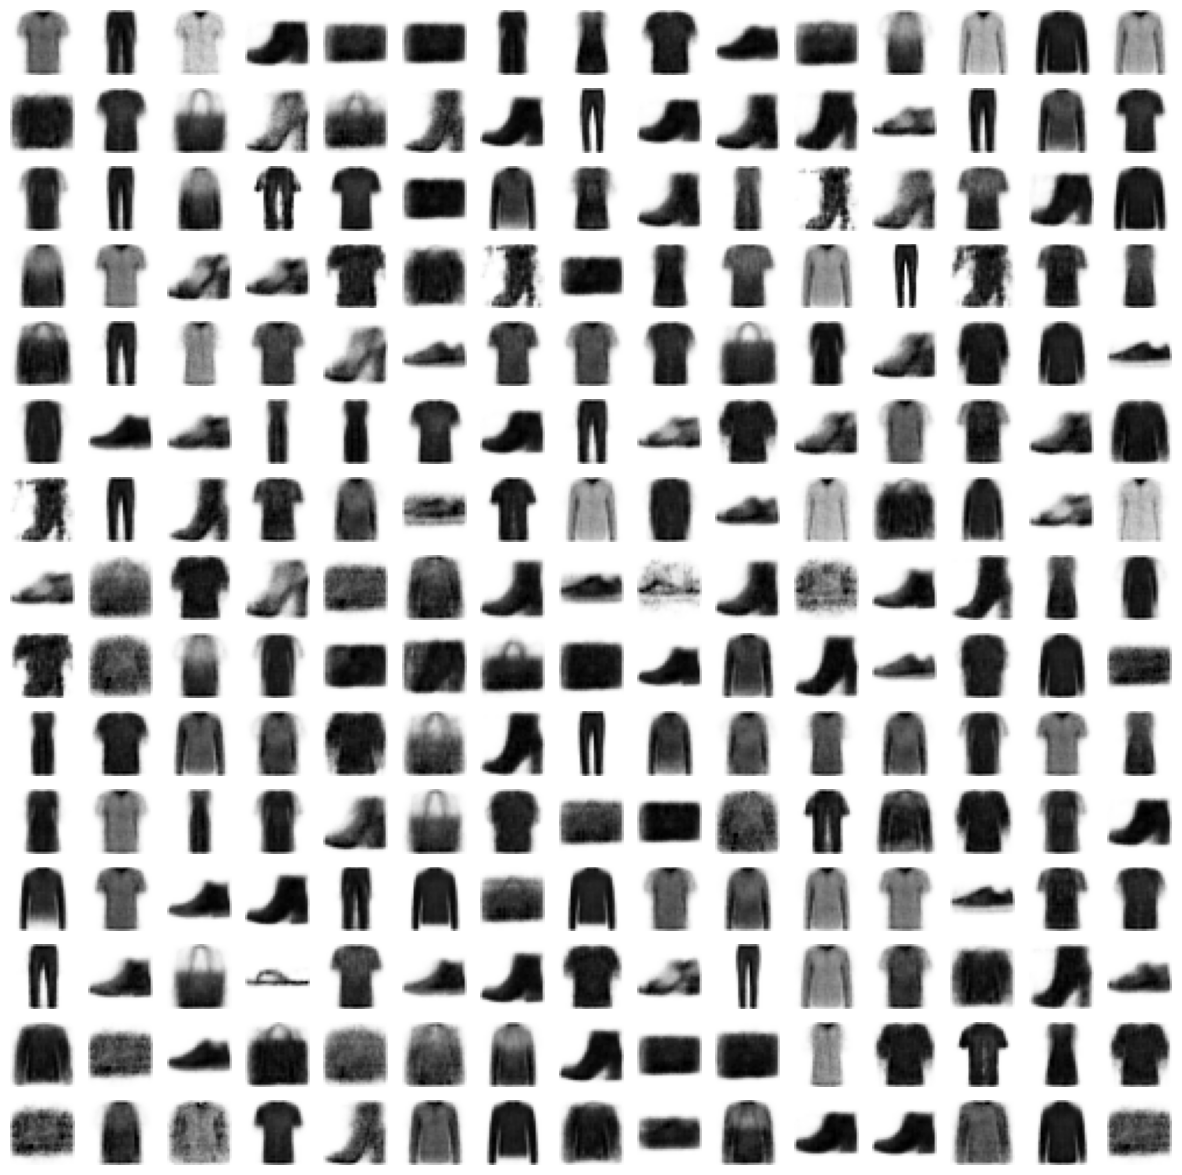

In [ ]:
def plot_nuevas_prendas(decoder_model, n=15, latent_dim=LATENT_DIM):
    print("\nGenerando nueva ropa desde el espacio latente:")
    plt.figure(figsize=(15, 15))

    # 1. Crear vectores latentes aleatorios
    vectores_latentes = tf.random.normal(shape=(n * n, latent_dim))

    # 2. Generar imágenes con el decoder
    imagenes_generadas = decoder_model.predict(vectores_latentes, verbose=0)

    for i in range(n * n):
        ax = plt.subplot(n, n, i + 1)
        plt.imshow(imagenes_generadas[i].reshape(28, 28), cmap="binary")
        plt.axis("off")
    plt.show()

# Llamada a la función
plot_nuevas_prendas(vae.decoder)

### 6.2. Visualización del Espacio Latente

Usa la función `plot_espacio_latente` proporcionada. Esta función usará el encoder de tu VAE para proyectar las imágenes de prueba en el espacio latente 2D y las coloreará según su clase real.


Visualizando el espacio latente 2D:


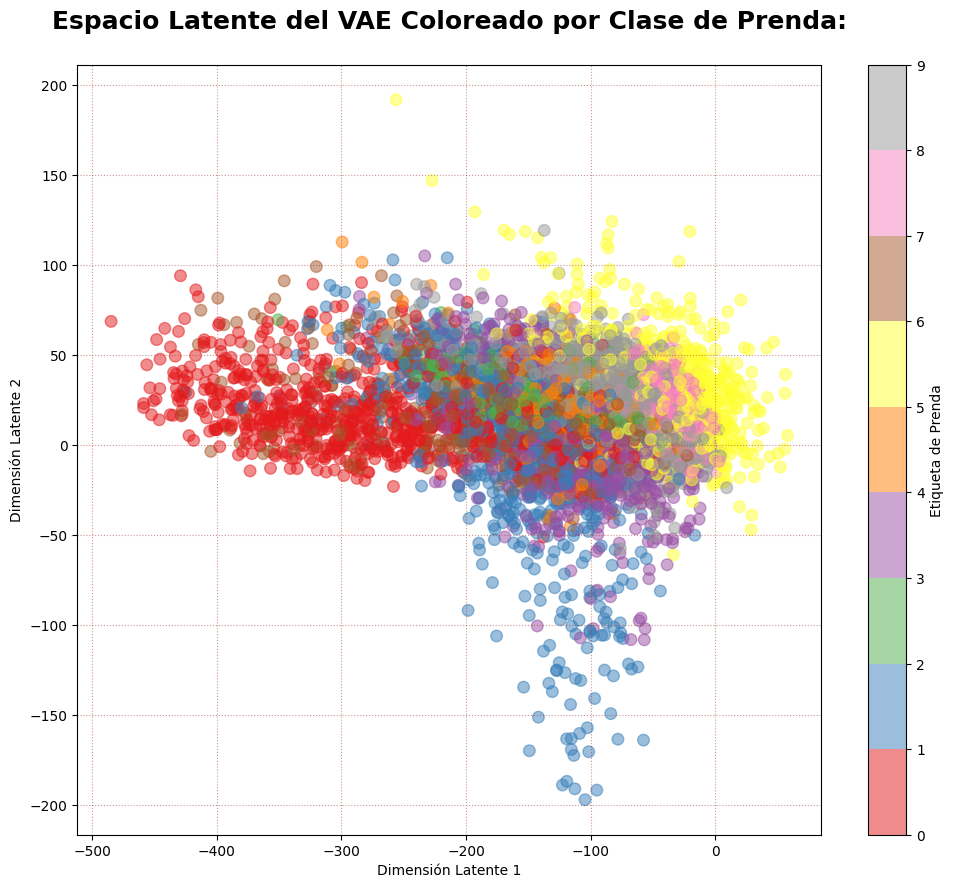

In [ ]:
def plot_espacio_latente(encoder_model, data, labels):
    print("\nVisualizando el espacio latente 2D:")

    # 1. Usamos el encoder para proyectar los datos de prueba a 2D.
    # El encoder devuelve [z_mean, z_log_var], solo necesitamos z_mean para la posición en el mapa.
    z_mean, _ = encoder_model.predict(data.reshape(-1, 28, 28, 1), verbose=0)

    plt.figure(figsize=(12, 10))

    # 2. Creamos un diagrama de dispersión. Cada punto es una imagen.
    # La posición (x, y) del punto viene de las dos dimensiones de z_mean.
    # El color 'c' del punto viene de su etiqueta real 'labels'.
    plt.scatter(z_mean[:, 0], z_mean[:, 1], c=labels, cmap="Set1", alpha=0.5, s=70)
    plt.colorbar(label="Etiqueta de Prenda")
    plt.xlabel("Dimensión Latente 1")
    plt.ylabel("Dimensión Latente 2")
    plt.title("Espacio Latente del VAE Coloreado por Clase de Prenda:\n", fontsize = 18, fontweight='bold')
    plt.grid(alpha = 0.5, c = 'brown', ls=':')
    plt.show()

# Usamos los datos de prueba originales para la visualización
plot_espacio_latente(vae.encoder, x_test, y_test)

### 6.3. Generación desde el Mapa Latente

Finalmente, usa la función plot_mapa_generativo para crear una cuadrícula de imágenes generadas. Cada imagen corresponderá a un punto en una cuadrícula uniforme de nuestro espacio latente 2D. Esto nos mostrará cómo una prenda se transforma suavemente en otra a medida que nos movemos por el mapa


Generando prendas desde una cuadrícula en el espacio latente:


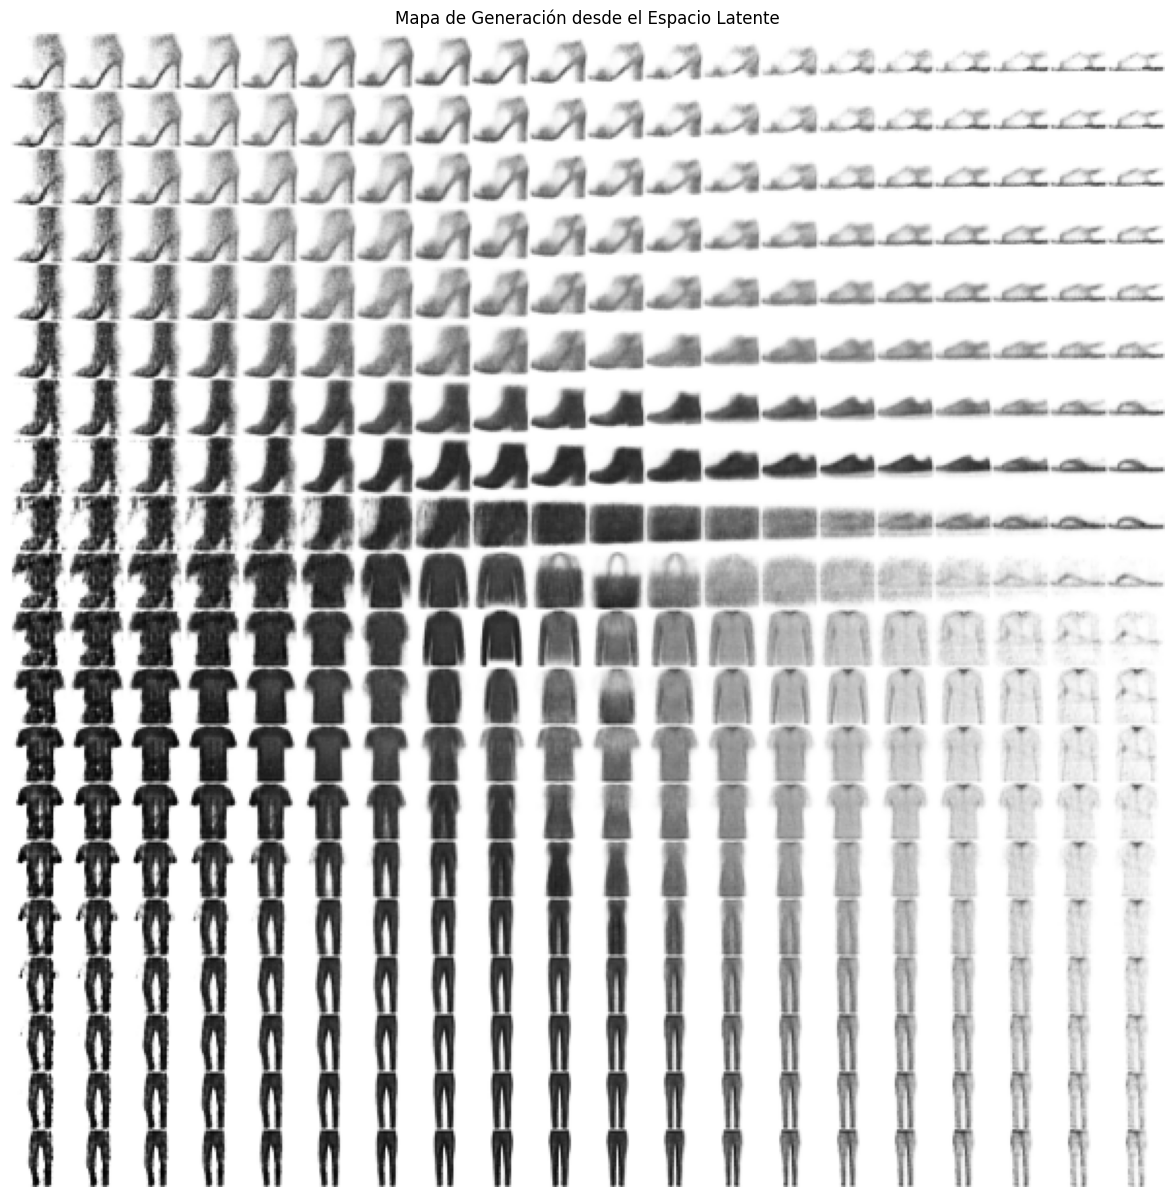

In [ ]:
def plot_mapa_generativo(decoder_model, n=20, figsize=15):
    print("\nGenerando prendas desde una cuadrícula en el espacio latente:")

    # 1. Crear una cuadrícula de coordenadas en el espacio latente 2D.
    # np.linspace(-3, 3, n) crea 'n' puntos espaciados uniformemente entre -3 y 3.
    x = np.linspace(-3, 3, n)
    y = np.linspace(-3, 3, n)[::-1] # Invertimos el eje y para que coincida con la visualización de imágenes
    grid_x, grid_y = np.meshgrid(x, y)
    vectores_latentes_grid = np.c_[grid_x.ravel(), grid_y.ravel()] # Combina todo en una lista de puntos (x,y)

    # 2. Generar una imagen para cada punto de la cuadrícula
    imagenes_generadas = decoder_model.predict(vectores_latentes_grid, verbose=0)

    canvas = np.zeros((28 * n, 28 * n))
    for i in range(n * n):
        canvas[(i // n) * 28 : (i // n + 1) * 28, (i % n) * 28 : (i % n + 1) * 28] = imagenes_generadas[i].reshape(28, 28)

    plt.figure(figsize=(figsize, figsize))
    plt.imshow(canvas, cmap="binary")
    plt.title("Mapa de Generación desde el Espacio Latente")
    plt.axis("off")
    plt.show()

plot_mapa_generativo(vae.decoder)